In [2]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

In [3]:
image=cv2.imread('dawg.png')
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0844496314786896..2.2868666244331544].


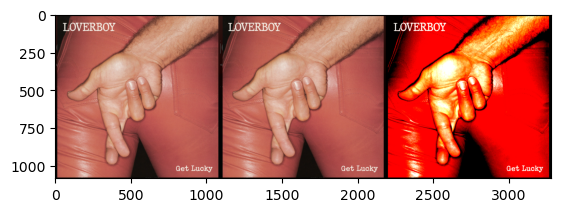

In [4]:
standardized=(image-image.mean())/image.std()
normalized=(image-image.min())/(image.max()-image.min())
combined=np.hstack((image/255.0,normalized,standardized))
plt.imshow(combined)
plt.show()

In [5]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.032280160972686..2.552854030501089].


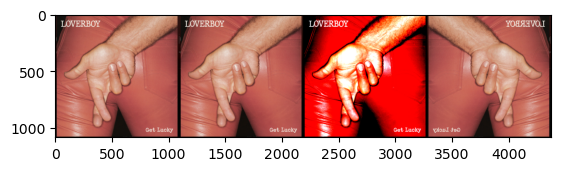

In [6]:
standardized=(image/255.0-IMAGENET_MEAN)/IMAGENET_STD
normalized=(image-image.min())/(image.max()-image.min())
flipped=cv2.flip(image/255,1)
combined=np.hstack((image/255.0,normalized,standardized,flipped))
plt.imshow(combined)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322801609726864..2.458627450980392].


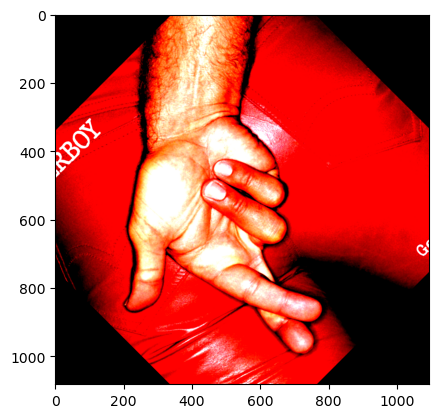

In [7]:
center=(image.shape[1]//2,image.shape[0]//2)
angle=45
rotate_matrix=cv2.getRotationMatrix2D(center,angle,scale=1)
rotate_image=cv2.warpAffine(standardized,rotate_matrix,(image.shape[1],image.shape[0]))
plt.imshow(rotate_image)
plt.show()

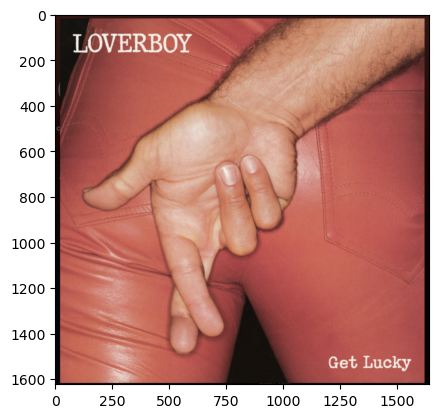

(1082, 1094, 3) (1623, 1641, 3)


In [8]:
scaled=cv2.resize(image,None ,fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)

plt.imshow(scaled)
plt.show()
print(image.shape,scaled.shape)

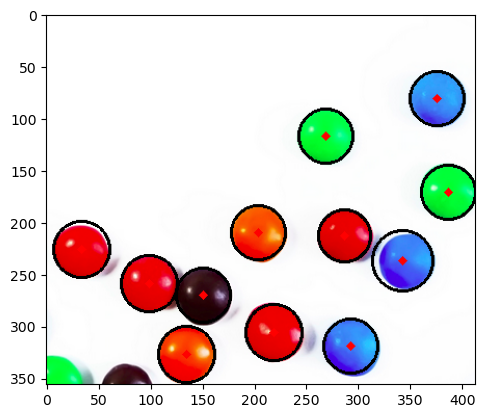

In [ ]:
import cv2
import numpy as np

img = cv2.imread("smarties.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# IMPORTANT: reduce noise
gray = cv2.GaussianBlur(gray, (9, 9), 1.5)

circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=50,
    param1=100,
    param2=30,
    minRadius=20,
    maxRadius=100
)
if circles is not None:
    circles=circles.astype('uint16')
    for x, y, r in circles[0]:
        cv2.circle(img, (x, y), r, (0, 0, 0), 2)
        cv2.circle(img, (x, y), 2, (0, 0, 255), 3)

plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.show()

In [28]:
radii=(np.transpose(circles[0])[2])
radii.shape[0]
np.min(radii)

np.uint16(25)

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(image_path,blur_kernel=9):
    image=cv2.imread(image_path)
    grayscale=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(grayscale, (blur_kernel, blur_kernel),1)
    return blur

def detect_circles(gray_image,dp=1,minDist=50,param1=100,param2=30,minRadius=20,maxRadius=100):
    circles=cv2.HoughCircles(gray_image,dp=dp,minDist=minDist,param1=param1,param2=param2,minRadius=minRadius,maxRadius=maxRadius)
    return circles

def visualize_circles(image,circles, save_path=None):
    if circles is not None:
        circles=circles.astype('uint16')
        for x, y, r in circles[0]:
            cv2.circle(image, (x, y), r, (0, 0, 0),1)
            cv2.circle(image, (x, y), 2, (0, 0, 255), 2)
    else:
        print("No valid circles recognized")
    if save_path is not None:
        cv2.imwrite(os.path.expanduser(save_path + '/sketch.jpg'), image)
    return image

def calculate_statistics(circles):
    radii=np.transpose(circles[0])[2]
    print("The number of circles are ",radii.shape[0])
    print("The smallest radius found in the set is ",np.min(radii))
    print("The largest radius found in the set is ",np.max(radii))
    print("The average radius in the set is ", np.average(radii))
    
def save_statistics(save_path=None):
    if save_path is not None:
        with open(save_path+'/output.txt', "w") as f:
            f.write(f"The number of circles are {radii.shape[0]}\nThe smallest radius found in the set is {np.min(radii)}\nThe largest radius found in the set is {np.max(radii)}\nThe average radius in the set is {np.average(radii)}")

print('test')
    
def main():
    circles=detect_circles(preprocess_image('smarties.png'))
    visualization=visualize_circles(image, circles)
    plt.imshow(visualization)
    plt.show()
    calculate_statistics(circles)
    
if __name__=='__main__':
    main()

test


error: OpenCV(4.12.0) :-1: error: (-5:Bad argument) in function 'HoughCircles'
> Overload resolution failed:
>  - HoughCircles() missing required argument 'method' (pos 2)
>  - HoughCircles() missing required argument 'method' (pos 2)


In [2]:
import torch

In [4]:
x=torch.randn(1,3,32,32)

In [5]:
type(x)

torch.Tensor

In [6]:
print(x)

tensor([[[[-0.6390, -1.8242, -0.0887,  ..., -0.9659, -1.6560, -0.0537],
          [ 0.2324, -0.4592,  0.0541,  ...,  0.6905,  0.0462, -0.2711],
          [-0.7417, -2.0138, -0.6005,  ...,  0.1547,  0.9434, -0.9909],
          ...,
          [ 0.9322,  0.4989,  0.8398,  ...,  0.5293, -1.7642,  0.1855],
          [-0.9891,  0.5525, -0.9000,  ..., -1.2252,  0.0459,  1.4665],
          [-0.6447,  1.7942,  0.4393,  ..., -1.5986,  0.4208,  0.5577]],

         [[ 0.1715, -0.6606,  0.9250,  ..., -2.2341,  0.0245, -0.0323],
          [-1.3407,  0.4429,  1.2068,  ...,  0.0198,  0.0441, -0.0834],
          [ 1.0937, -1.5208,  0.4252,  ..., -0.4860, -0.0997,  0.9148],
          ...,
          [-0.1742, -0.9002,  0.0137,  ..., -0.9597, -0.5417,  0.6591],
          [-0.0873, -0.8063, -0.7334,  ..., -0.4021, -0.0462,  1.6803],
          [ 0.2770, -0.0057,  0.0347,  ..., -1.3879,  0.4749, -0.4100]],

         [[-0.0647, -0.6117,  0.0197,  ..., -0.4426, -0.0213,  1.4723],
          [-0.4781,  0.3413, -

TypeError: Invalid shape (1, 3, 32, 32) for image data

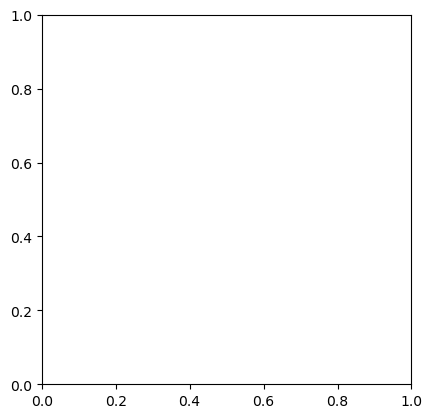

In [9]:
import matplotlib.pyplot as plt
plt.imshow(x)
plt.show()